In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv('/content/olist_orders_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')

In [3]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Sellers:", sellers.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)


In [4]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nOrder Items columns:")
print(order_items.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Order Items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Products columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [5]:
# Check missing values in each dataset

datasets = {
    "Orders": orders,
    "Customers": customers,
    "Order Items": order_items,
    "Products": products,
    "Payments": payments,
    "Reviews": reviews,
    "Sellers": sellers
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(df.isnull().sum())


Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm  

In [6]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Orders: 0 duplicate rows
Customers: 0 duplicate rows
Order Items: 0 duplicate rows
Products: 0 duplicate rows
Payments: 0 duplicate rows
Reviews: 0 duplicate rows
Sellers: 0 duplicate rows


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
# Convert date columns to datetime

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [10]:
orders[date_columns].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [11]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [12]:
orders.groupby('order_status')[date_columns].apply(
    lambda x: x.isnull().sum()
)

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,
approved,0,0,2,2,0
canceled,0,141,550,619,0
created,0,5,5,5,0
delivered,0,14,2,8,0
invoiced,0,0,314,314,0
processing,0,0,301,301,0
shipped,0,0,0,1107,0
unavailable,0,0,609,609,0


In [13]:
# Create a cleaned copy of orders

processed_orders = orders.copy()

# Keep only delivered orders for delivery-time analysis
delivered_orders = processed_orders[
    processed_orders['order_status'] == 'delivered'
].copy()

print("Total orders:", len(processed_orders))
print("Delivered orders:", len(delivered_orders))

Total orders: 99441
Delivered orders: 96478


In [14]:
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

print(delivered_orders['delivery_days'].isnull().sum())

8


In [15]:
# Check the 8 delivered orders with missing delivery date
delivered_orders[
    delivered_orders['delivery_days'].isna()
][[
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,NaT,2018-07-19


In [16]:
# Remove orders where delivery date is missing
delivered_orders_clean = delivered_orders.dropna(
    subset=['order_delivered_customer_date']
).copy()

print("Before cleaning:", len(delivered_orders))
print("After cleaning:", len(delivered_orders_clean))
print("Missing delivery days:",
      delivered_orders_clean['delivery_days'].isna().sum())

Before cleaning: 96478
After cleaning: 96470
Missing delivery days: 0


In [17]:
# Basic statistics of delivery time
delivered_orders_clean['delivery_days'].describe()

,delivery_days
count,96470.000000
mean,12.558217
std,9.546156
min,0.533414
25%,6.766204
50%,10.217477
75%,15.720182
max,209.628611


In [18]:
# Check unusually high delivery times
delivered_orders_clean[
    delivered_orders_clean['delivery_days'] > 60
][[
    'order_id',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'delivery_days'
]].sort_values('delivery_days', ascending=False).head(20)

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-09-19 14:36:39,209.628611
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-09-19 23:24:07,208.351759
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-09-19 15:12:50,195.634016
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-09-19 14:33:17,194.850174
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-09-19 14:00:04,194.633611
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-09-19 14:38:21,194.049583
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-07-13 20:51:31,191.463542
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-09-19 17:00:07,189.863160
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-09-19 14:38:18,188.134618
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-09-19 17:14:25,187.743843


In [19]:
# Create late delivery flag
delivered_orders_clean['is_late'] = (
    delivered_orders_clean['order_delivered_customer_date']
    > delivered_orders_clean['order_estimated_delivery_date']
)

# Count late and on-time orders
print(delivered_orders_clean['is_late'].value_counts())

# Calculate late delivery percentage
late_percentage = delivered_orders_clean['is_late'].mean() * 100

print(f"Late delivery percentage: {late_percentage:.2f}%")

is_late
False    88644
True      7826
Name: count, dtype: int64
Late delivery percentage: 8.11%


In [20]:
delivered_orders_clean.groupby('is_late')['delivery_days'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
is_late,,,,,
False,88644,10.88426,9.727442,0.533414,70.213611
True,7826,31.51889,29.154659,2.129537,209.628611


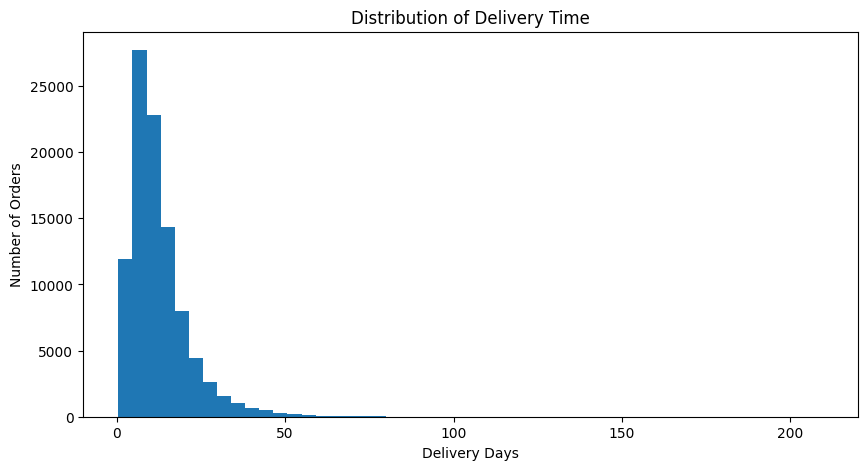

In [21]:
import matplotlib.pyplot as plt

# Delivery time distribution
plt.figure(figsize=(10, 5))
plt.hist(
    delivered_orders_clean['delivery_days'],
    bins=50
)
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Delivery Time')
plt.show()

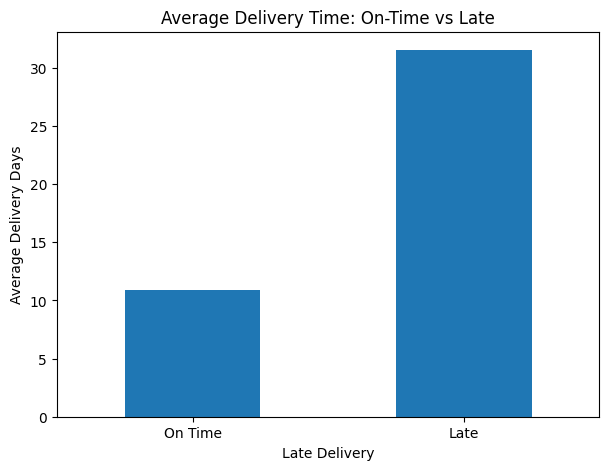

In [22]:
# Compare on-time vs late deliveries
plt.figure(figsize=(7, 5))

delivered_orders_clean.groupby('is_late')['delivery_days'].mean().plot(
    kind='bar'
)

plt.xlabel('Late Delivery')
plt.ylabel('Average Delivery Days')
plt.title('Average Delivery Time: On-Time vs Late')
plt.xticks([0, 1], ['On Time', 'Late'], rotation=0)
plt.show()

In [23]:
# Extract purchase month
delivered_orders_clean['purchase_month'] = (
    delivered_orders_clean['order_purchase_timestamp'].dt.to_period('M')
)

# Calculate monthly late-delivery rate
monthly_late_rate = (
    delivered_orders_clean
    .groupby('purchase_month')['is_late']
    .mean()
    .mul(100)
    .reset_index(name='late_percentage')
)

monthly_late_rate

,purchase_month,late_percentage
0,2016-09,100.000000
1,2016-10,1.132075
2,2016-12,0.000000
3,2017-01,3.066667
4,2017-02,3.206292
5,2017-03,5.577376
6,2017-04,7.859314
7,2017-05,3.610719
8,2017-06,3.859649
9,2017-07,3.434917


In [24]:
monthly_late_rate.sort_values(
    'late_percentage',
    ascending=False
).head(10)

,purchase_month,late_percentage
0,2016-09,100.000000
17,2018-03,21.362273
16,2018-02,15.987796
13,2017-11,14.311196
22,2018-08,10.392064
14,2017-12,8.380192
19,2018-05,8.238258
6,2017-04,7.859314
15,2018-01,6.563870
5,2017-03,5.577376


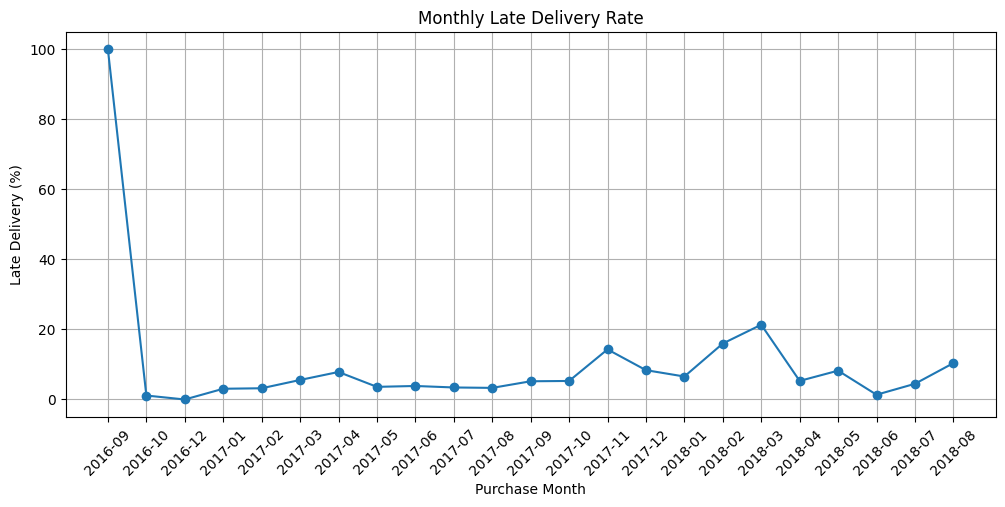

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_late_rate['purchase_month'].astype(str),
    monthly_late_rate['late_percentage'],
    marker='o'
)

plt.xlabel('Purchase Month')
plt.ylabel('Late Delivery (%)')
plt.title('Monthly Late Delivery Rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [26]:
# Load product-related datasets
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
category_translation = pd.read_csv(
    '/content/product_category_name_translation.csv'
)

# Connect orders → order items → products
category_orders = delivered_orders_clean[
    ['order_id', 'is_late', 'delivery_days']
].merge(
    order_items[['order_id', 'product_id']],
    on='order_id',
    how='left'
).merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Translate Portuguese category names to English
category_orders = category_orders.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

category_orders.head()

,order_id,is_late,delivery_days,product_id,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,False,8.436574,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,False,13.782037,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,False,9.394213,aa4383b373c6aca5d8797843e5594415,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,False,13.208750,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,False,2.873877,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,stationery


In [27]:
category_orders = category_orders.drop_duplicates(
    subset=['order_id', 'product_category_name']
)

print("Rows after removing duplicates:", len(category_orders))

Rows after removing duplicates: 97268


In [28]:
category_summary = (
    category_orders
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        late_orders=('is_late', 'sum'),
        avg_delivery_days=('delivery_days', 'mean')
    )
    .reset_index()
)

category_summary['late_percentage'] = (
    category_summary['late_orders']
    / category_summary['orders']
    * 100
)

category_summary.sort_values(
    'orders',
    ascending=False
).head(15)

,product_category_name_english,orders,late_orders,avg_delivery_days,late_percentage
7,bed_bath_table,9272,811,12.990189,8.746764
43,health_beauty,8647,775,12.075152,8.962646
65,sports_leisure,7529,584,12.238978,7.756674
15,computers_accessories,6529,503,13.172150,7.704089
39,furniture_decor,6307,535,13.074519,8.482638
49,housewares,5743,399,11.086187,6.947588
70,watches_gifts,5493,468,12.805952,8.519934
68,telephony,4093,349,12.958875,8.526753
5,auto,3809,328,12.330584,8.611184
69,toys,3803,286,11.731824,7.520379


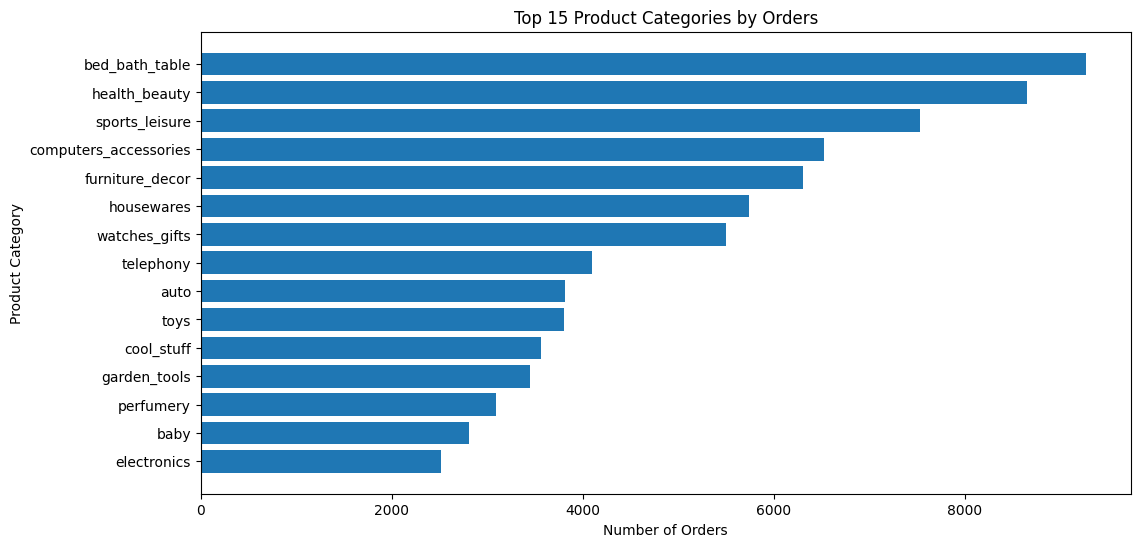

In [29]:
top_categories = category_summary.sort_values(
    'orders',
    ascending=False
).head(15)

plt.figure(figsize=(12, 6))

plt.barh(
    top_categories['product_category_name_english'],
    top_categories['orders']
)

plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
plt.title('Top 15 Product Categories by Orders')
plt.gca().invert_yaxis()
plt.show()

In [30]:
# Focus on categories with at least 100 orders
category_late_analysis = category_summary[
    category_summary['orders'] >= 100
].sort_values(
    'late_percentage',
    ascending=False
)

category_late_analysis.head(15)

,product_category_name_english,orders,late_orders,avg_delivery_days,late_percentage
4,audio,348,45,13.470062,12.931034
33,fashion_underwear_beach,117,15,14.002583,12.820513
10,books_technical,256,28,10.634351,10.937500
47,home_confort,392,41,13.712452,10.459184
36,food,441,44,9.792273,9.977324
26,electronics,2517,247,12.916719,9.813270
12,christmas_supplies,125,12,15.374882,9.600000
6,baby,2809,258,12.676481,9.184763
57,office_furniture,1254,115,20.638580,9.170654
17,construction_tools_construction,736,67,10.855906,9.103261


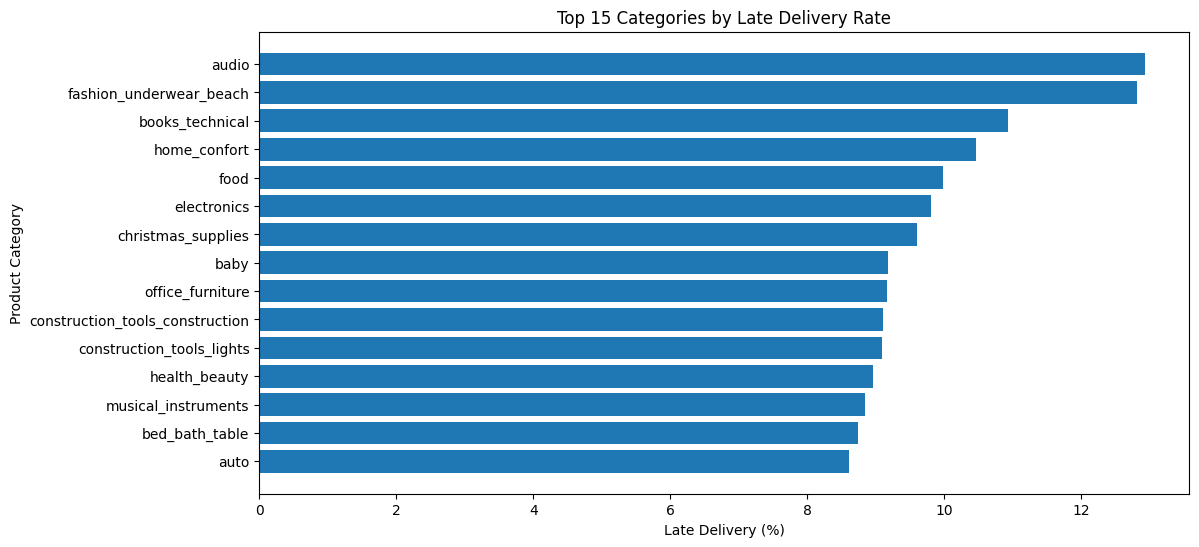

In [31]:
top_late_categories = category_late_analysis.head(15)

plt.figure(figsize=(12, 6))

plt.barh(
    top_late_categories['product_category_name_english'],
    top_late_categories['late_percentage']
)

plt.xlabel('Late Delivery (%)')
plt.ylabel('Product Category')
plt.title('Top 15 Categories by Late Delivery Rate')
plt.gca().invert_yaxis()
plt.show()

In [32]:
top_late_categories[
    [
        'product_category_name_english',
        'orders',
        'late_orders',
        'late_percentage',
        'avg_delivery_days'
    ]
]

,product_category_name_english,orders,late_orders,late_percentage,avg_delivery_days
4,audio,348,45,12.931034,13.470062
33,fashion_underwear_beach,117,15,12.820513,14.002583
10,books_technical,256,28,10.937500,10.634351
47,home_confort,392,41,10.459184,13.712452
36,food,441,44,9.977324,9.792273
26,electronics,2517,247,9.813270,12.916719
12,christmas_supplies,125,12,9.600000,15.374882
6,baby,2809,258,9.184763,12.676481
57,office_furniture,1254,115,9.170654,20.638580
17,construction_tools_construction,736,67,9.103261,10.855906


In [33]:
# Connect delivered orders with seller information
seller_orders = delivered_orders_clean[
    ['order_id', 'is_late', 'delivery_days']
].merge(
    order_items[['order_id', 'seller_id']],
    on='order_id',
    how='left'
)

# Remove duplicate order-seller combinations
seller_orders = seller_orders.drop_duplicates(
    subset=['order_id', 'seller_id']
)

print("Seller-order records:", len(seller_orders))
seller_orders.head()

Seller-order records: 97811


,order_id,is_late,delivery_days,seller_id
0,e481f51cbdc54678b7cc49136f2d6af7,False,8.436574,3504c0cb71d7fa48d967e0e4c94d59d9
1,53cdb2fc8bc7dce0b6741e2150273451,False,13.782037,289cdb325fb7e7f891c38608bf9e0962
2,47770eb9100c2d0c44946d9cf07ec65d,False,9.394213,4869f7a5dfa277a7dca6462dcf3b52b2
3,949d5b44dbf5de918fe9c16f97b45f8a,False,13.208750,66922902710d126a0e7d26b0e3805106
4,ad21c59c0840e6cb83a9ceb5573f8159,False,2.873877,2c9e548be18521d1c43cde1c582c6de8


In [34]:
seller_summary = (
    seller_orders
    .groupby('seller_id')
    .agg(
        orders=('order_id', 'nunique'),
        late_orders=('is_late', 'sum'),
        avg_delivery_days=('delivery_days', 'mean')
    )
    .reset_index()
)

seller_summary['late_percentage'] = (
    seller_summary['late_orders']
    / seller_summary['orders']
    * 100
)

seller_summary.sort_values(
    'orders',
    ascending=False
).head(15)

,seller_id,orders,late_orders,avg_delivery_days,late_percentage
1190,6560211a19b47992c3666cc44a7e94c0,1819,117,9.627302,6.432106
858,4a3ca9315b744ce9f8e9374361493884,1772,195,14.486045,11.004515
2388,cc419e0650a3c5ba77189a1882b7556a,1651,101,11.586278,6.117505
358,1f50f920176fa81dab994f9023523100,1399,148,15.809260,10.578985
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,100,11.186555,7.627765
1758,955fee9216a65b617aa5c0531780ce60,1261,98,10.769857,7.771610
1450,7a67c85e85bb2ce8582c35f2203ad736,1145,68,11.200218,5.938865
2725,ea8482cd71df3c1969d7b9473ff13abc,1132,118,13.323273,10.424028
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,130,15.062424,11.565836
712,3d871de0142ce09b7081e2b9d1733cb1,1064,63,13.510275,5.921053


In [35]:
seller_late_analysis = seller_summary[
    seller_summary['orders'] >= 100
].sort_values(
    'late_percentage',
    ascending=False
)

seller_late_analysis.head(15)

,seller_id,orders,late_orders,avg_delivery_days,late_percentage
79,06a2c3af7b3aee5d69171b0e14f0ee87,389,90,17.728176,23.136247
323,1ca7077d890b907f89be8c954a02686a,108,24,15.536054,22.222222
1606,88460e8ebdecbfecb5f9601833981930,246,48,17.799441,19.512195
2657,e5a3438891c0bfdb9394643f95273d8e,216,40,15.663078,18.518519
2404,cd68562d3f44870c08922d380acae552,122,22,16.261455,18.032787
1532,8160255418d5aaa7dbdc9f4c64ebda44,380,63,16.249577,16.578947
513,2c9e548be18521d1c43cde1c582c6de8,124,20,13.678750,16.129032
2577,dd7ddc04e1b6c2c614352b383efe2d36,121,19,15.020833,15.702479
2877,f7ba60f8c3f99e7ee4042fdef03b70c4,218,34,13.405900,15.596330
781,431af27f296bc6519d890aa5a05fdb11,116,18,17.234933,15.517241


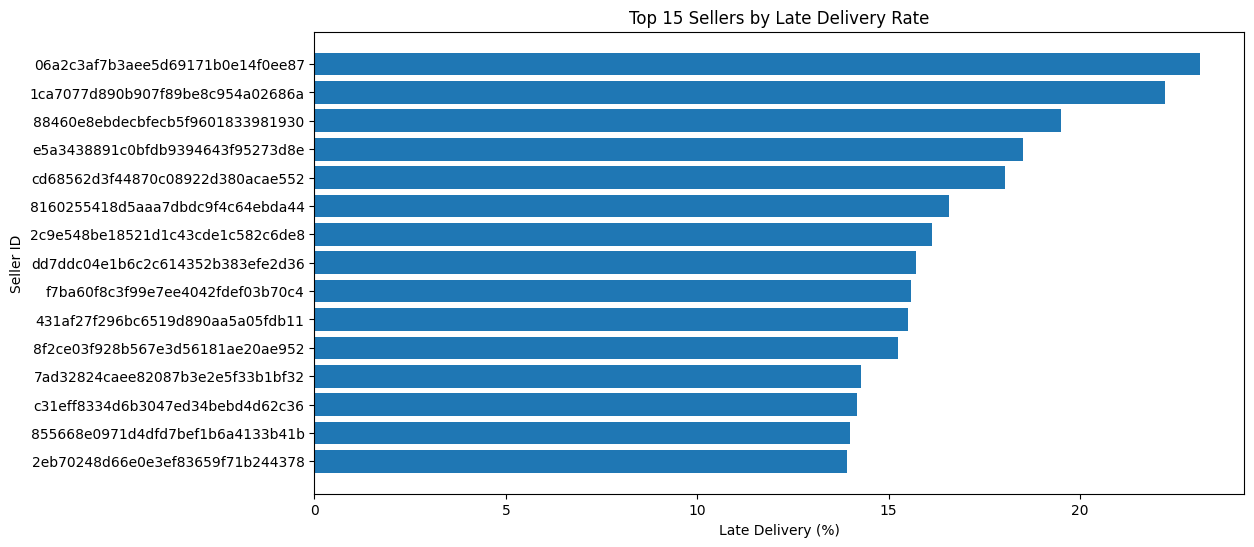

In [36]:
top_late_sellers = seller_late_analysis.head(15)

plt.figure(figsize=(12, 6))

plt.barh(
    top_late_sellers['seller_id'].astype(str),
    top_late_sellers['late_percentage']
)

plt.xlabel('Late Delivery (%)')
plt.ylabel('Seller ID')
plt.title('Top 15 Sellers by Late Delivery Rate')
plt.gca().invert_yaxis()
plt.show()

In [37]:
# Load review dataset
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')

print("Total reviews:", len(reviews))
reviews[['order_id', 'review_score']].head()

Total reviews: 99224


,order_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,4
1,a548910a1c6147796b98fdf73dbeba33,5
2,f9e4b658b201a9f2ecdecbb34bed034b,5
3,658677c97b385a9be170737859d3511b,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,5


In [38]:
# Connect customer reviews with delivery information
review_delivery = delivered_orders_clean[
    ['order_id', 'is_late', 'delivery_days']
].merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

print("Orders with delivery + review data:", len(review_delivery))
review_delivery.head()

Orders with delivery + review data: 96353


,order_id,is_late,delivery_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,False,8.436574,4
1,53cdb2fc8bc7dce0b6741e2150273451,False,13.782037,4
2,47770eb9100c2d0c44946d9cf07ec65d,False,9.394213,5
3,949d5b44dbf5de918fe9c16f97b45f8a,False,13.208750,5
4,ad21c59c0840e6cb83a9ceb5573f8159,False,2.873877,5


In [39]:
review_summary = (
    review_delivery
    .groupby('is_late')['review_score']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

review_summary['is_late'] = review_summary['is_late'].map({
    False: 'On Time',
    True: 'Late'
})

review_summary

,is_late,count,mean,median
0,On Time,88653,4.293718,5.0
1,Late,7700,2.566494,2.0


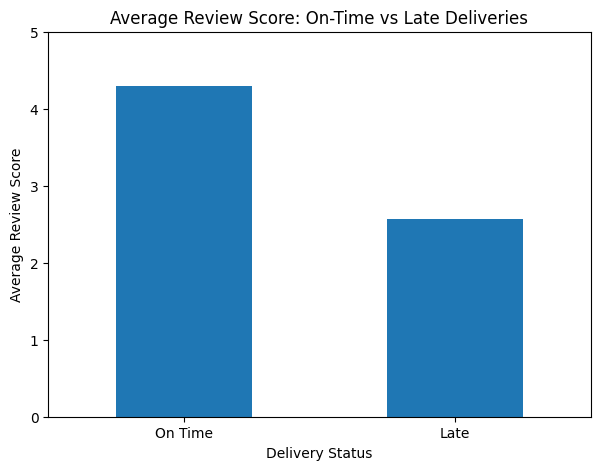

In [40]:
plt.figure(figsize=(7, 5))

review_delivery.groupby('is_late')['review_score'].mean().plot(
    kind='bar'
)

plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.title('Average Review Score: On-Time vs Late Deliveries')
plt.xticks([0, 1], ['On Time', 'Late'], rotation=0)
plt.ylim(0, 5)
plt.show()

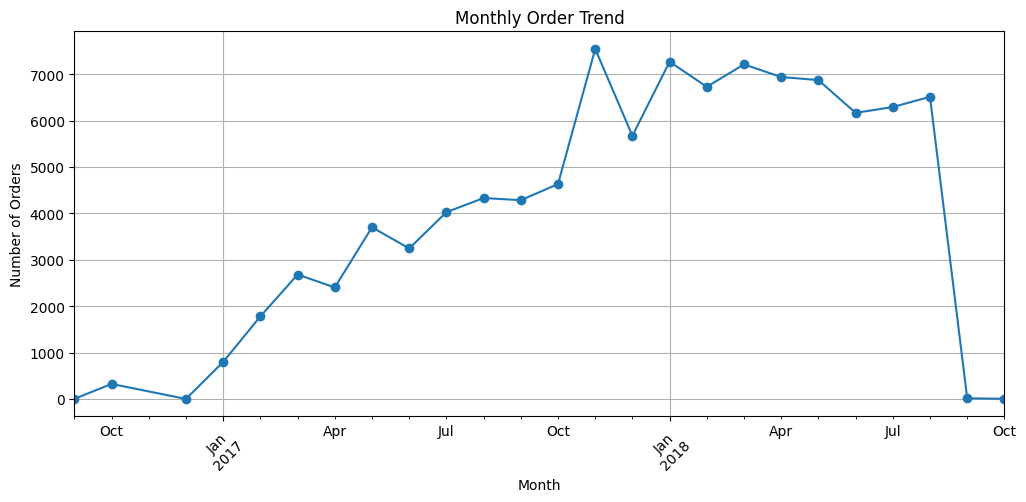

In [41]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('month').size()

monthly_orders.plot(
    kind='line',
    marker='o',
    figsize=(12, 5)
)

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

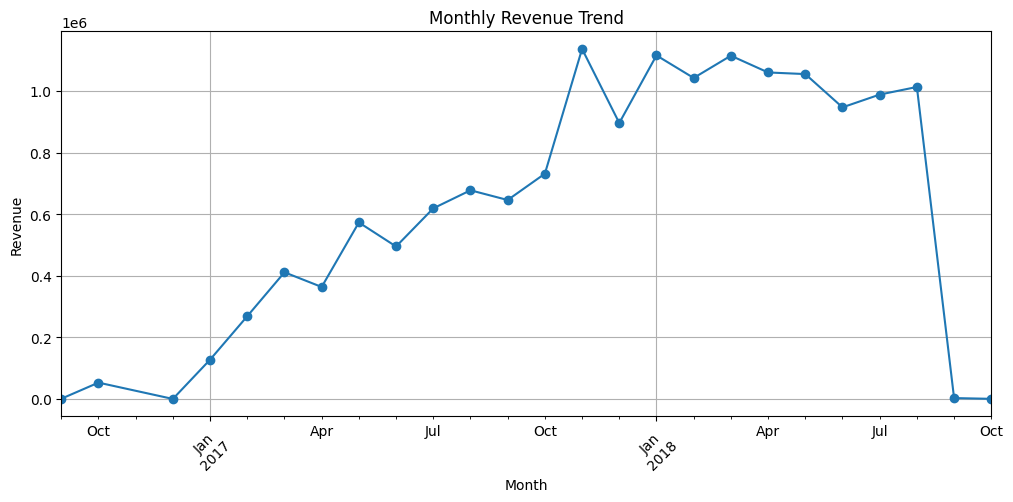

In [42]:
monthly_revenue = payments.copy()

payments['payment_value'] = pd.to_numeric(
    payments['payment_value'],
    errors='coerce'
)

payments['payment_date'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

payments['month'] = payments['payment_date'].dt.to_period('M')

monthly_revenue = payments.groupby('month')['payment_value'].sum()

monthly_revenue.plot(
    kind='line',
    marker='o',
    figsize=(12, 5)
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

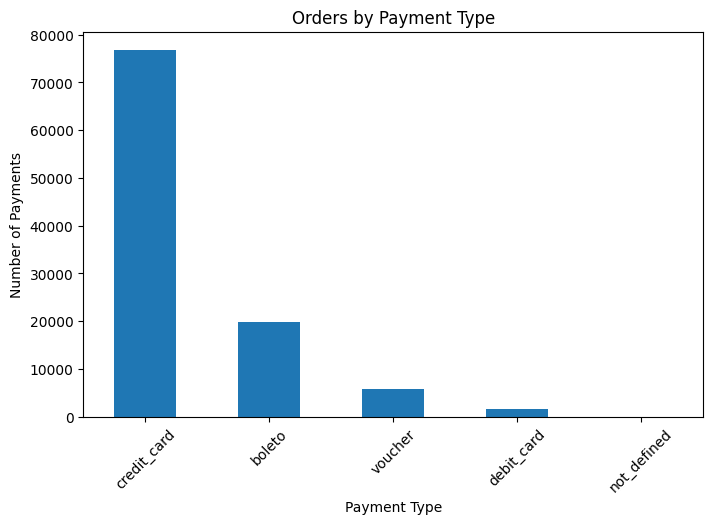

In [43]:
# Payment type analysis

payment_type_counts = payments['payment_type'].value_counts()

payment_type_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Orders by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Payments')
plt.xticks(rotation=45)
plt.show()

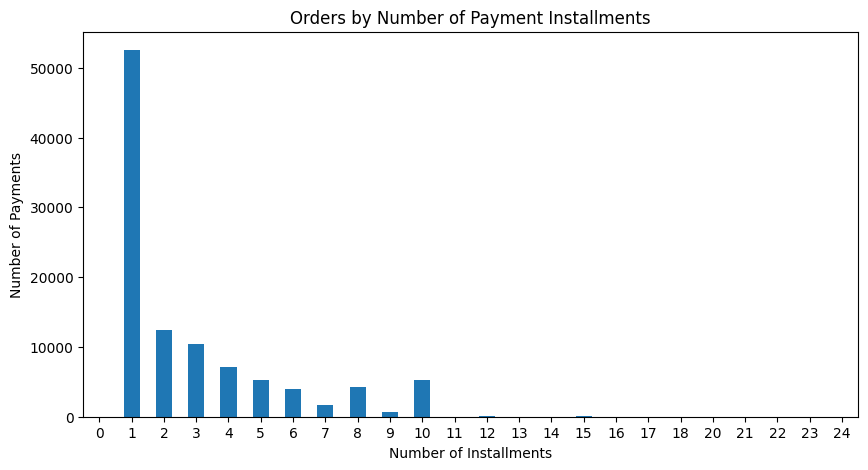

In [44]:
# Payment installments analysis

installment_counts = payments['payment_installments'].value_counts().sort_index()

installment_counts.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Orders by Number of Payment Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Number of Payments')
plt.xticks(rotation=0)
plt.show()

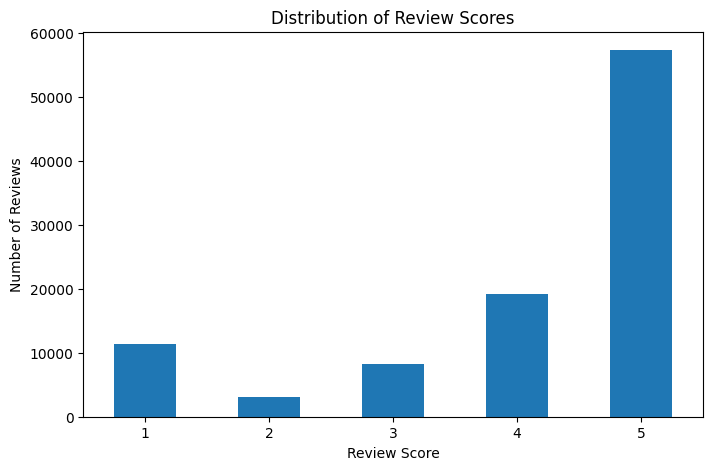

In [45]:
# Review score distribution

review_counts = reviews['review_score'].value_counts().sort_index()

review_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

In [46]:
# Calculate item-level revenue
order_items['item_revenue'] = (
    order_items['price'] +
    order_items['freight_value']
)

# Add product category
category_revenue = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Translate category names
category_revenue = category_revenue.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# Revenue by category
revenue_by_category = (
    category_revenue
    .groupby('product_category_name_english')['item_revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_category.head(15)

,product_category_name_english,item_revenue
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
5,furniture_decor,902511.79
6,housewares,778397.77
7,cool_stuff,719329.95
8,auto,685384.32
9,garden_tools,584219.21


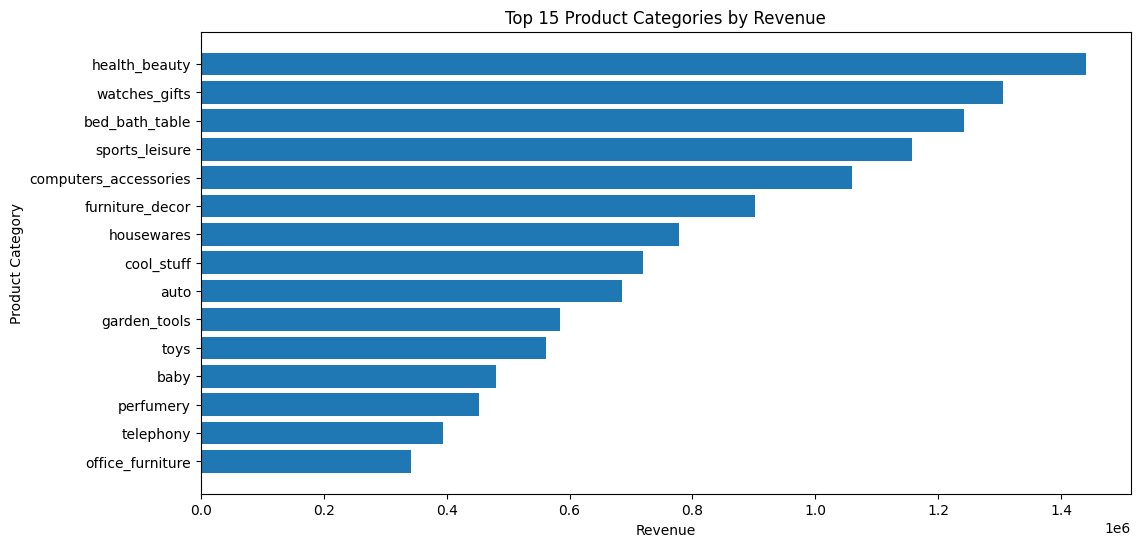

In [47]:
top_revenue_categories = revenue_by_category.head(15)

plt.figure(figsize=(12, 6))

plt.barh(
    top_revenue_categories['product_category_name_english'],
    top_revenue_categories['item_revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.title('Top 15 Product Categories by Revenue')
plt.gca().invert_yaxis()
plt.show()

In [48]:
# Calculate revenue for each order

order_revenue = (
    order_items
    .groupby('order_id')['item_revenue']
    .sum()
    .reset_index()
)

order_revenue.columns = ['order_id', 'order_revenue']

# Average Order Value
aov = order_revenue['order_revenue'].mean()

print(f"Total Revenue: {order_revenue['order_revenue'].sum():,.2f}")
print(f"Total Orders: {order_revenue['order_id'].nunique():,}")
print(f"Average Order Value: {aov:,.2f}")

Total Revenue: 15,843,553.24
Total Orders: 98,666
Average Order Value: 160.58


In [49]:
order_revenue['order_revenue'].describe()

,order_revenue
count,98666.000000
mean,160.577638
std,220.466087
min,9.590000
25%,61.980000
50%,105.290000
75%,176.870000
max,13664.080000


In [50]:
# Merge delivered orders with customer information
state_orders = delivered_orders_clean[
    ['order_id', 'customer_id', 'is_late', 'delivery_days']
].merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

# State-wise summary
state_summary = (
    state_orders
    .groupby('customer_state')
    .agg(
        orders=('order_id', 'nunique'),
        late_orders=('is_late', 'sum'),
        avg_delivery_days=('delivery_days', 'mean')
    )
    .reset_index()
)

# Calculate late delivery percentage
state_summary['late_percentage'] = (
    state_summary['late_orders']
    / state_summary['orders']
    * 100
)

# Sort by number of orders
state_summary = state_summary.sort_values(
    'orders',
    ascending=False
)

state_summary.head(10)

,customer_state,orders,late_orders,avg_delivery_days,late_percentage
25,SP,40494,2387,8.761386,5.894700
18,RJ,12350,1664,15.309438,13.473684
10,MG,11354,637,12.008666,5.610358
22,RS,5344,382,15.300276,7.148204
17,PR,4923,246,11.991582,4.996953
23,SC,3546,346,14.954783,9.757473
4,BA,3256,457,19.335466,14.035627
6,DF,2080,147,12.967568,7.067308
7,ES,1995,244,15.789307,12.230576
8,GO,1957,160,15.606339,8.175779


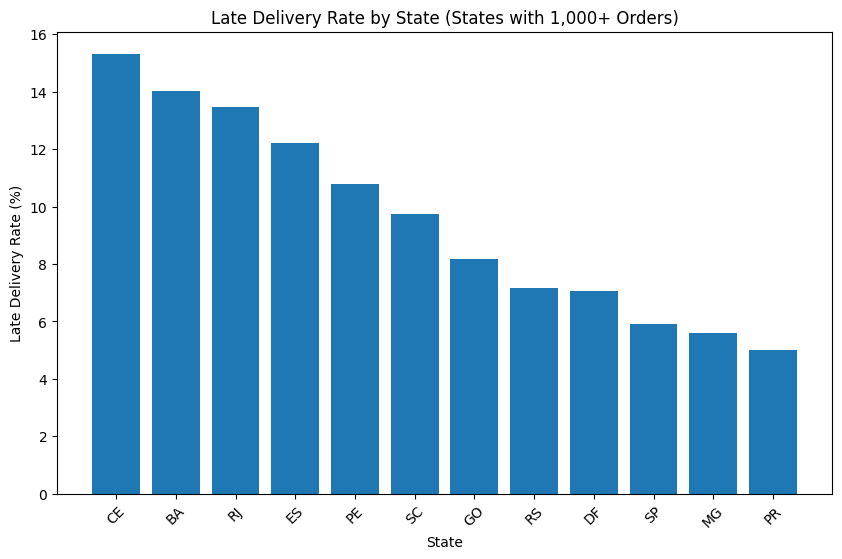

In [51]:
# Select states with at least 1,000 orders
state_late_analysis = (
    state_summary[state_summary['orders'] >= 1000]
    .sort_values('late_percentage', ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    state_late_analysis['customer_state'],
    state_late_analysis['late_percentage']
)

plt.xlabel('State')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by State (States with 1,000+ Orders)')
plt.xticks(rotation=45)
plt.show()

In [54]:
# ==============================
# FINAL ANALYSIS SUMMARY
# ==============================

print("1. DELIVERY PERFORMANCE")
print(f"Delivered orders: {len(delivered_orders_clean):,}")
print(f"Late orders: {delivered_orders_clean['is_late'].sum():,}")
print(f"Late delivery rate: {delivered_orders_clean['is_late'].mean()*100:.2f}%")
print(f"Average delivery time: {delivered_orders_clean['delivery_days'].mean():.2f} days")
print(f"Maximum delivery time: {delivered_orders_clean['delivery_days'].max():.2f} days")

print("\n2. REVENUE")
print(f"Total order value: {order_revenue['order_revenue'].sum():,.2f}")
print(f"Orders with order value: {order_revenue['order_id'].nunique():,}")
print(f"Average Order Value: {order_revenue['order_revenue'].mean():,.2f}")

print("\n3. REVIEW PERFORMANCE")
print(review_summary)

print("\n4. TOP CATEGORIES BY ORDERS")
print(category_summary.sort_values('orders', ascending=False).head(10)[
    ['product_category_name_english', 'orders', 'late_percentage']
])

print("\n5. TOP CATEGORIES BY REVENUE")
print(revenue_by_category.head(10))

print("\n6. HIGHEST LATE-RATE SELLERS (100+ ORDERS)")
print(seller_late_analysis.head(10)[
    ['seller_id', 'orders', 'late_percentage', 'avg_delivery_days']
])

print("\n7. HIGHEST LATE-RATE STATES (1,000+ ORDERS)")
print(state_late_analysis.head(10)[
    ['customer_state', 'orders', 'late_percentage', 'avg_delivery_days']
])

print("\n8. MONTHLY LATE RATE")
print(monthly_late_rate.sort_values('late_percentage', ascending=False).head(10))

1. DELIVERY PERFORMANCE
Delivered orders: 96,470
Late orders: 7,826
Late delivery rate: 8.11%
Average delivery time: 12.56 days
Maximum delivery time: 209.63 days

2. REVENUE
Total order value: 15,843,553.24
Orders with order value: 98,666
Average Order Value: 160.58

3. REVIEW PERFORMANCE
   is_late  count      mean  median
0  On Time  88653  4.293718     5.0
1     Late   7700  2.566494     2.0

4. TOP CATEGORIES BY ORDERS
   product_category_name_english  orders  late_percentage
7                 bed_bath_table    9272         8.746764
43                 health_beauty    8647         8.962646
65                sports_leisure    7529         7.756674
15         computers_accessories    6529         7.704089
39               furniture_decor    6307         8.482638
49                    housewares    5743         6.947588
70                 watches_gifts    5493         8.519934
68                     telephony    4093         8.526753
5                           auto    3809         8

In [55]:
# ==========================================
# FINAL ANALYSIS-READY ORDER-LEVEL DATASET
# ==========================================

# Start with clean delivered orders
final_data = delivered_orders_clean[
    [
        'order_id',
        'customer_id',
        'order_status',
        'order_purchase_timestamp',
        'purchase_month',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'delivery_days',
        'is_late'
    ]
].copy()

# Add customer state and city
final_data = final_data.merge(
    customers[
        ['customer_id', 'customer_city', 'customer_state']
    ],
    on='customer_id',
    how='left'
)

# Calculate order value = product price + freight
order_value = (
    order_items
    .groupby('order_id')
    .agg(
        order_value=('item_revenue', 'sum'),
        total_items=('order_item_id', 'count'),
        seller_count=('seller_id', 'nunique')
    )
    .reset_index()
)

# Add order value information
final_data = final_data.merge(
    order_value,
    on='order_id',
    how='left'
)

# Add review score
final_data = final_data.merge(
    reviews[
        ['order_id', 'review_score']
    ],
    on='order_id',
    how='left'
)

# Create readable late status
final_data['delivery_status'] = np.where(
    final_data['is_late'],
    'Late',
    'On Time'
)

# Check final dataset
print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))
print("\nMissing values:")
print(final_data.isnull().sum())

print("\nFirst 5 rows:")
display(final_data.head())

Rows: 96999
Columns: 16

Missing values:
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
purchase_month                     0
order_delivered_customer_date      0
order_estimated_delivery_date      0
delivery_days                      0
is_late                            0
customer_city                      0
customer_state                     0
order_value                        0
total_items                        0
seller_count                       0
review_score                     646
delivery_status                    0
dtype: int64

First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,purchase_month,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,customer_city,customer_state,order_value,total_items,seller_count,review_score,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10,2017-10-10 21:25:13,2017-10-18,8.436574,False,sao paulo,SP,38.71,1,1,4.0,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07,2018-08-07 15:27:45,2018-08-13,13.782037,False,barreiras,BA,141.46,1,1,4.0,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08,2018-08-17 18:06:29,2018-09-04,9.394213,False,vianopolis,GO,179.12,1,1,5.0,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11,2017-12-02 00:28:42,2017-12-15,13.208750,False,sao goncalo do amarante,RN,72.20,1,1,5.0,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02,2018-02-16 18:17:02,2018-02-26,2.873877,False,santo andre,SP,28.62,1,1,5.0,On Time


In [56]:
# ==========================================
# FINAL DATA QUALITY VALIDATION
# ==========================================

print("===== FINAL DATASET VALIDATION =====")

# 1. Row and column count
print(f"Rows: {final_data.shape[0]:,}")
print(f"Columns: {final_data.shape[1]}")

# 2. Duplicate orders
print(f"\nDuplicate order IDs: {final_data['order_id'].duplicated().sum():,}")

# 3. Missing values
print("\nMissing values:")
print(final_data.isnull().sum())

# 4. Data types
print("\nData types:")
print(final_data.dtypes)

# 5. Delivery status
print("\nDelivery status:")
print(final_data['delivery_status'].value_counts())

# 6. Basic business metrics
print("\nBusiness metrics:")
print(f"Average delivery days: {final_data['delivery_days'].mean():.2f}")
print(f"Late delivery rate: {final_data['is_late'].mean()*100:.2f}%")
print(f"Average order value: {final_data['order_value'].mean():.2f}")
print(f"Average review score: {final_data['review_score'].mean():.2f}")

print("\n===== VALIDATION COMPLETE =====")

===== FINAL DATASET VALIDATION =====
Rows: 96,999
Columns: 16

Duplicate order IDs: 529

Missing values:
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
purchase_month                     0
order_delivered_customer_date      0
order_estimated_delivery_date      0
delivery_days                      0
is_late                            0
customer_city                      0
customer_state                     0
order_value                        0
total_items                        0
seller_count                       0
review_score                     646
delivery_status                    0
dtype: int64

Data types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
purchase_month                        period[M]
order_delivered_customer_date    date

In [57]:
# ==========================================
# FIX REVIEW DUPLICATES
# ==========================================

# Keep one review score per order
# If an order has multiple reviews, use the average score
review_per_order = (
    reviews
    .groupby('order_id')['review_score']
    .mean()
    .reset_index()
)

# Rebuild final dataset
final_data = delivered_orders_clean[
    [
        'order_id',
        'customer_id',
        'order_status',
        'order_purchase_timestamp',
        'purchase_month',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'delivery_days',
        'is_late'
    ]
].copy()

# Customer information
final_data = final_data.merge(
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

# Order value and item information
final_data = final_data.merge(
    order_value,
    on='order_id',
    how='left'
)

# Add ONE review score per order
final_data = final_data.merge(
    review_per_order,
    on='order_id',
    how='left'
)

# Delivery status
final_data['delivery_status'] = np.where(
    final_data['is_late'],
    'Late',
    'On Time'
)

# Final validation
print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))
print("Unique orders:", final_data['order_id'].nunique())
print("Duplicate order IDs:", final_data['order_id'].duplicated().sum())

print("\nMissing review scores:")
print(final_data['review_score'].isnull().sum())

print("\nDelivery status:")
print(final_data['delivery_status'].value_counts())

Rows: 96470
Columns: 16
Unique orders: 96470
Duplicate order IDs: 0

Missing review scores:
646

Delivery status:
delivery_status
On Time    88644
Late        7826
Name: count, dtype: int64


In [58]:
# Save final analysis-ready dataset
final_data.to_csv(
    '/content/olist_processed_data.csv',
    index=False
)

print("Processed dataset saved successfully.")
print("File: olist_processed_data.csv")
print(f"Rows: {len(final_data):,}")
print(f"Columns: {len(final_data.columns)}")

Processed dataset saved successfully.
File: olist_processed_data.csv
Rows: 96,470
Columns: 16


In [59]:
# ==========================================
# Q5 - EXTREME DELIVERY DELAYS
# ==========================================

extreme_deliveries = final_data[
    final_data['delivery_days'] > 60
].copy()

print(f"Orders taking more than 60 days: {len(extreme_deliveries):,}")

print("\nDelivery statistics for extreme orders:")
print(
    extreme_deliveries['delivery_days']
    .describe()
)

print("\nTop 10 longest deliveries:")
display(
    extreme_deliveries[
        [
            'order_id',
            'customer_state',
            'delivery_days',
            'order_value',
            'review_score',
            'delivery_status'
        ]
    ]
    .sort_values('delivery_days', ascending=False)
    .head(10)
)

Orders taking more than 60 days: 306

Delivery statistics for extreme orders:
count    306.000000
mean      86.752096
std       34.357038
min       60.017998
25%       65.974227
50%       71.997876
75%       90.719852
max      209.628611
Name: delivery_days, dtype: float64

Top 10 longest deliveries:


,order_id,customer_state,delivery_days,order_value,review_score,delivery_status
19029,ca07593549f1816d26a572e06dc1eab6,ES,209.628611,245.68,NaN,Late
53963,1b3190b2dfa9d789e1f14c05b647a14a,RJ,208.351759,162.25,2.0,Late
59778,440d0d17af552815d15a9e41abe49359,PA,195.634016,185.02,1.0,Late
68207,2fb597c2f772eca01b1f5c561bf6cc7b,PI,194.850174,345.15,4.0,Late
86459,285ab9426d6982034523a855f55a885e,SE,194.633611,457.65,1.0,Late
37371,0f4519c5f1c541ddec9f21b3bddd533a,PI,194.049583,259.15,4.0,Late
11074,47b40429ed8cce3aee9199792275433f,SP,191.463542,453.33,1.0,Late
78961,2fe324febf907e3ea3f2aa9650869fa5,SP,189.863160,55.95,1.0,Late
52862,2d7561026d542c8dbd8f0daeadf67a43,SE,188.134618,53.70,3.0,Late
66712,c27815f7e3dd0b926b58552628481575,MG,187.743843,535.90,3.0,Late


In [60]:
from google.colab import files

files.download('/content/olist_processed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>